# COMPSCI 714 — Coding Assignment 1 Notebook - S1 2026

**Student name:** Xincheng Li

**Student UPI:**  xli798

**Student ID:**  168277355

**GenAI policy**  
This is a Lane 2 assignment, meaning you are authorised to use GenAI tools as support to complete the work. 
You may use Generative AI tools to support your coding and understanding, but not to complete the assignment for you.

*You may use GenAI to:*
- debug errors and understand code,
- clarify concepts (e.g., recall, loss functions, saliency maps),
- get guidance on how to implement components (e.g., training loops, Optuna setup).

*You should not use GenAI to:*
- generate full solutions and submit them as your own,
- copy code you do not understand,
- produce written answers not based on your own results.

*Key expectation*

You must be able to explain your code and justify your results.

**GenAI usage disclosure:** 

For transparency and self-reflection purpose, state here whether you used any Generative AI tools, and if so, briefly describe how it helped you complete the assignment:

-

---

# Instructions

This notebook is a **submission template** for the assignment, including both instructions and cells to implement and enter your answers.

## How to use this notebook
For each task, you will usually find:
1. an **Instructions/Requirements/Required outputs** section explaining what the task is about, what outputs are expected, and any additional requirements,
2. one or more **TODO code cell** with code to run, complete and/or write from scratch,
3. a **Comment your results** section to enter short written comments to specified questions.

## General requirements
- Fill your name, UPI, ID at the top of the Notebook.
- Complete the GenAI usage disclosure at the top of the Notebook.
- Complete all required `TODO` cells. Some of them are prefilled and you need to replace `None` values and/or complete part of the code as instructed. 
- Answer all the **Comment your results** questions directly in the Notebook in the markdown cell.
- Run your notebook from top to bottom before submission.
- Keep outputs visible.
- Do **not** delete task headings.
- You may add extra cells if needed, but label them clearly.
- Use the provided random seed unless instructed otherwise.
- Keep variable names clear and consistent.

## What markers will check
Markers will check that:
- your code follows the task specifications,
- required outputs are shown,
- written answers are coherent, concise (a few sentences are enough) and refer to your **actual numerical results** when relevant,
- the notebook is globally readable and well structured.

## Notebook checklist before submitting
Before submitting, make sure:
- your name, UPI and ID are stated at the start of the Notebook.
- you disclosed GenAI usage at the top of the Notebook.
- all cells run without errors,
- all required outputs are visible,
- all written response sections are completed,
- plots have readable titles/labels where relevant,
- the final notebook is neat and easy to mark.


# Setup

Import libraries and set random seeds for reproducibility.


In [1]:
# TODO: Run this cell first

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_recall_curve

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

# You may need to install Optuna if it is not available in your environment.
!pip install optuna
import optuna
from optuna.samplers import TPESampler

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


# Part 1 — Train and evaluate a simple MLP on tabular data (11 marks)

## Learning goal
In Part 1, your goal is to **apply, adapt and expand code patterns from Lectutorials 1 to 3** on a simple dataset.

This part focuses on:
- correctly adapting standard preprocessing tools,
- comparing random splitting and stratified splitting,
- implementing and training a simple MLP on the stratified split,
- interpreting model performance using losses and multiple evaluation metrics.
- analyse the precision-recall trade-off on the task using the precision-recall curve.
- tuning hyperparameters and comparing their importance. 


## Task 1.1 — Load and inspect the dataset (1 mark)

### Instructions
Use the OpenML dataset `German-Credit-Risk-with-Target`, loaded with the fetch_openml function.

You must:
1. load the dataset into `X` (features) and `y` (targets),
2. inspect its structure,
3. identify potential missing values,
4. identify numeric and categorical features.

### Required outputs (0.5 marks)
Show:
- the shape of `X`,
- the class distribution of the target,
- the number of numeric features and the number of categorical features,
- the name, non-null count and data type of each feature,
- a preview of the 5 first rows of `X`.

In [2]:
# TODO: Complete this dataset loading and inspection guide

# Step 1: load the dataset from OpenML
data = fetch_openml(name='German-Credit-Risk-with-Target', version=1, as_frame=True)

# Step 2: extract features and target (hint: the features and targets are stored in specific attributes of the loaded dataset)
X = data.data
y = data.target

# Step 3: identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

# Step 4: print the required outputs
print(f"Shape of X: {X.shape}")

print(f"\nClass distribution of target:")
print(y.value_counts())

print(f"\nNumber of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")
print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

print(f"\nFeature info:")
print(X.info())

print(f"\nFirst 5 rows of X:")
X.head()

Shape of X: (1000, 9)

Class distribution of target:
Risk
good    700
bad     300
Name: count, dtype: int64

Number of numeric features: 4
Number of categorical features: 5

Numeric features: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical features: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

Feature info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1000 non-null   int64   
 1   Sex               1000 non-null   category
 2   Job               1000 non-null   int64   
 3   Housing           1000 non-null   category
 4   Saving accounts   817 non-null    category
 5   Checking account  606 non-null    category
 6   Credit amount     1000 non-null   int64   
 7   Duration          1000 non-null   int64   
 8   Purpose           1000 non-null   str     
dtypes: category(4), int64(4), str(1

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [3]:
# The number of missing values per column
mv_per_col = X.isna().sum()
print("Missing values per feature:")
print(mv_per_col)

# The total number of missing values
total_missing = mv_per_col.sum()
print("\nTotal missing values:", total_missing)

Missing values per feature:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

Total missing values: 577


### Comment your results (0.5 marks)
Briefly describe:
- what type of prediction task this is,
- whether the dataset is mixed-type (numeric + categorical),
- whether there are missing values and in what attribute(s),
- whether the classes appear roughly balanced or imbalanced.

**Your answer:**  

- 🌟 This is a **binary classification** task with the target variable `Risk` (good/bad risk), where the goal is to predict whether a credit applicant is a good or bad risk.

- 🌟 The dataset is **mixed-type**, containing both 4 numeric features (e.g., Age, Job, Credit amount and Duration) and 5 categorical features (e.g., Sex, Housing, Saving accounts, Checking account, Purpose).

- 🌟 Regarding missing values, there are **577 missing values** in total, found in the feature(s): Saving accounts, Checking account.

- 🌟 The class distribution shows {'good': 700, 'bad': 300} — the dataset is **moderately imbalanced**, with approximately 70% "good" and 30% "bad" credit risk instances, meaning the majority class ("good") is about 2.3 times more frequent than the minority class ("bad").


## Task 1.2 — Compare random and stratified splitting (1 mark)

### Instructions
Create **two versions** of the train/validation/test sets:
1. a **random split without stratification**,
2. a **stratified split**.

For both versions, split the dataset into 70% training, 15% validation, and 15% test sets.

### Requirements
- Use `random_state=seed` in all splits.
- For the stratified version, stratify on the target variable.

### Required outputs (0.5 marks)
Show, for **both** random and stratified splitting:
- the number of samples in each set.
- the class proportions in each set.

In [4]:
# TODO: Complete this splitting guide

# Random split (no stratification)
X_train_rand, X_temp_rand, y_train_rand, y_temp_rand = train_test_split(
    X, y, test_size=0.30, random_state=seed)
X_valid_rand, X_test_rand, y_valid_rand, y_test_rand = train_test_split(
    X_temp_rand, y_temp_rand, test_size=0.50, random_state=seed)

# Stratified split
X_train_strat, X_temp_strat, y_train_strat, y_temp_strat = train_test_split(
    X, y, test_size=0.30, random_state=seed, stratify=y)
X_valid_strat, X_test_strat, y_valid_strat, y_test_strat = train_test_split(
    X_temp_strat, y_temp_strat, test_size=0.50, random_state=seed, stratify=y_temp_strat)


def class_proportions(y_split):
    return y_split.value_counts(normalize=True).sort_index()

# TODO: print sets sizes and class proportions for both strategies
print("========== Random Split ==========")
print("The number of samples in each set:")
print(f"Train set: {len(X_train_rand)}, Valid set: {len(X_valid_rand)}, Test set: {len(X_test_rand)}")
print("\nThe class proportions in each set:")
print(f"Train class proportions:\n{class_proportions(y_train_rand)}")
print(f"Valid class proportions:\n{class_proportions(y_valid_rand)}")
print(f"Test class proportions:\n{class_proportions(y_test_rand)}")

print("\n========== Stratified Split ==========")
print("The number of samples in each set:")
print(f"Train set: {len(X_train_strat)}, Valid set: {len(X_valid_strat)}, Test set: {len(X_test_strat)}")
print("\nThe class proportions in each set:")
print(f"Train class proportions:\n{class_proportions(y_train_strat)}")
print(f"Valid class proportions:\n{class_proportions(y_valid_strat)}")
print(f"Test class proportions:\n{class_proportions(y_test_strat)}")

print(f"\n==========Original class proportions==========\n{class_proportions(y)}")


========== Random Split ==========
The number of samples in each set:
Train set: 700, Valid set: 150, Test set: 150

The class proportions in each set:
Train class proportions:
Risk
bad     0.298571
good    0.701429
Name: proportion, dtype: float64
Valid class proportions:
Risk
bad     0.34
good    0.66
Name: proportion, dtype: float64
Test class proportions:
Risk
bad     0.266667
good    0.733333
Name: proportion, dtype: float64

========== Stratified Split ==========
The number of samples in each set:
Train set: 700, Valid set: 150, Test set: 150

The class proportions in each set:
Train class proportions:
Risk
bad     0.3
good    0.7
Name: proportion, dtype: float64
Valid class proportions:
Risk
bad     0.3
good    0.7
Name: proportion, dtype: float64
Test class proportions:
Risk
bad     0.3
good    0.7
Name: proportion, dtype: float64

==========Original class proportions==========
Risk
bad     0.3
good    0.7
Name: proportion, dtype: float64


### Comment your results (0.5 marks)
Use your numerical results to compare the two splitting approaches.

Discuss:
- how similar or different the class proportions are across train, validation, and test,
- which approach appears more reliable for this dataset, and why.

**Your answer:**
  
-  🌟 With the **random split**, the class proportions vary noticeably across sets (e.g., training set has 29.9% good vs. 70.1% bad, while the test set has 26.7% good vs. 73.3% bad). In contrast, the **stratified split** maintains nearly identical class proportions across all three sets (approximately 30.0%/70.0%), closely matching the original dataset distribution. The stratified approach is more reliable for this dataset because it ensures that the minority class ("bad" risk) is proportionally represented in each split. This is particularly important given the class imbalance — without stratification, some splits may under- or over-represent the minority class, leading to biased model training and unreliable evaluation metrics.


## Task 1.3 — Build the preprocessing pipeline (1 marks)

### Instructions
Build a preprocessing pipeline using `ColumnTransformer` and apply it to the **stratified sets**.

### Required preprocessing
- For numeric columns: median imputation and standard scaling.
- For categorical columns: most-frequent imputation and one-hot encoding with `handle_unknown="ignore"`.

### Important rule
Fit the preprocessing pipeline on the **training set only**, then transform validation and test sets.

### Required outputs (0.5 marks)
Show:
- the numeric pipeline,
- the categorical pipeline,
- the preprocessing `ColumnTransformer` object showing which pipeline is applied to which features,
- processed shapes for train / validation / test sets.


In [5]:
# TODO: Complete this preprocessing guide
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess_strat = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit on training set only, then transform all sets
X_train_strat_proc = preprocess_strat.fit_transform(X_train_strat)
X_valid_strat_proc = preprocess_strat.transform(X_valid_strat)
X_test_strat_proc = preprocess_strat.transform(X_test_strat)

# Also preprocess random split for Task 1.4
preprocess_rand = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])
X_train_rand_proc = preprocess_rand.fit_transform(X_train_rand)
X_valid_rand_proc = preprocess_rand.transform(X_valid_rand)
X_test_rand_proc = preprocess_rand.transform(X_test_rand)

# TODO: Show pipelines, preprocessing strat and print processed sets shapes
print("========== Numeric pipeline ==========")
print(numeric_pipeline)

print("\n========== Categorical pipeline ==========")
print(categorical_pipeline)

print("\n========== Preprocessing ColumnTransformer ==========")
print(preprocess_strat)

print(f"\n=========== Processed shapes for train/validation/test sets ===========")
print(f"  Train: {X_train_strat_proc.shape}")
print(f"  Valid: {X_valid_strat_proc.shape}")
print(f"  Test:  {X_test_strat_proc.shape}")

========== Numeric pipeline ==========
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

========== Categorical pipeline ==========
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

========== Preprocessing ColumnTransformer ==========
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Job', 'Credit amount', 'Duration']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                   

### Enter your answers (0.5 marks)
Briefly justify:
- the number of features after applying the preprocessing pipelines,
- why the preprocessing must be fitted only on the training data.

**Your answer:**  

- 🌟 After preprocessing, the number of features increased from the original 9 to **24**. This is because the 4 numeric features are kept as-is (only scaled), while the 5 categorical features are one-hot encoded, expanding each categorical variable into multiple binary columns — one for each unique category observed in the training data. 
- 🌟 The preprocessing must be fitted **only on the training data** to prevent **data leakage**. If we fitted the scaler or encoder on the entire dataset (including validation and test sets), the model would indirectly gain information about the distribution of unseen data during training, leading to overly optimistic evaluation results that do not reflect real-world performance.


## Task 1.4 — Convert data to tensors and dataloaders (1 mark)

### Instructions
Convert the processed arrays to PyTorch tensors and create dataloaders.

### Requirements
- Inputs must use `torch.float32`.
- Labels must be converted to binary `0/1`.
- Use batch size `64`.

### Required outputs (0.5 marks)
Show:
- the observed target labels,
- the label mapping used,
- tensor shapes for all sets,
- the number of batches in the training, validation and test loaders. 


In [6]:
# TODO: Complete this tensor / dataloader guide
# Convert preprocessed numpy arrays to PyTorch tensors and create DataLoaders

# Also preprocess random split for Task 1.4
preprocess_rand = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])
X_train_rand_proc = preprocess_rand.fit_transform(X_train_rand)
X_valid_rand_proc = preprocess_rand.transform(X_valid_rand)
X_test_rand_proc = preprocess_rand.transform(X_test_rand)

# Display original target labels
label_values = y.unique()
print(f"Observed target labels: {sorted(label_values)}")

# Define label mapping: 'good' -> 0, 'bad' -> 1 (bad risk is the positive class)
label_map = {'good': 0, 'bad': 1}
print(f"\nLabel mapping: {label_map}")

# Helper function to encode string labels to numeric values
def encode_labels(y_series):
    return y_series.map(label_map).values.astype(np.float32)

# Encode labels for both split strategies
y_train_rand_num, y_valid_rand_num, y_test_rand_num = encode_labels(y_train_rand), encode_labels(y_valid_rand), encode_labels(y_test_rand)
y_train_strat_num, y_valid_strat_num, y_test_strat_num = encode_labels(y_train_strat), encode_labels(y_valid_strat), encode_labels(y_test_strat)

# Convert features to float32 tensors
X_train_rand_tensor = torch.tensor(X_train_rand_proc, dtype=torch.float32)
X_valid_rand_tensor = torch.tensor(X_valid_rand_proc, dtype=torch.float32)
X_test_rand_tensor = torch.tensor(X_test_rand_proc, dtype=torch.float32)
X_train_strat_tensor = torch.tensor(X_train_strat_proc, dtype=torch.float32)
X_valid_strat_tensor = torch.tensor(X_valid_strat_proc, dtype=torch.float32)
X_test_strat_tensor = torch.tensor(X_test_strat_proc, dtype=torch.float32)

# Convert labels to float32 tensors
y_train_rand_tensor = torch.tensor(y_train_rand_num, dtype=torch.float32)
y_valid_rand_tensor = torch.tensor(y_valid_rand_num, dtype=torch.float32)
y_test_rand_tensor = torch.tensor(y_test_rand_num, dtype=torch.float32)
y_train_strat_tensor = torch.tensor(y_train_strat_num, dtype=torch.float32)
y_valid_strat_tensor = torch.tensor(y_valid_strat_num, dtype=torch.float32)
y_test_strat_tensor = torch.tensor(y_test_strat_num, dtype=torch.float32)

# Create DataLoaders with batch size 64; shuffle training data only
batch_size = 64

train_loader_rand = DataLoader(TensorDataset(X_train_rand_tensor, y_train_rand_tensor), batch_size=batch_size, shuffle=True)
valid_loader_rand = DataLoader(TensorDataset(X_valid_rand_tensor, y_valid_rand_tensor), batch_size=batch_size)
test_loader_rand = DataLoader(TensorDataset(X_test_rand_tensor, y_test_rand_tensor), batch_size=batch_size)
train_loader_strat = DataLoader(TensorDataset(X_train_strat_tensor, y_train_strat_tensor), batch_size=batch_size, shuffle=True)
valid_loader_strat = DataLoader(TensorDataset(X_valid_strat_tensor, y_valid_strat_tensor), batch_size=batch_size)
test_loader_strat = DataLoader(TensorDataset(X_test_strat_tensor, y_test_strat_tensor), batch_size=batch_size)

# TODO: Display observed target labels, label mapping, print tensor shapes in sets and number of batches in loaders for both strategies
print(f"\n========== Tensor shapes ==========")
print("🌟Stratified-split tensor shapes:")
print(f"  X_train_strat: {X_train_strat_tensor.shape}, y_train_strat: {y_train_strat_tensor.shape}")
print(f"  X_valid_strat: {X_valid_strat_tensor.shape}, y_valid_strat: {y_valid_strat_tensor.shape}")
print(f"  X_test_strat:  {X_test_strat_tensor.shape}, y_test_strat:  {y_test_strat_tensor.shape}")
print("🌟Random-split tensor shapes:")
print(f"  X_train_rand:  {X_train_rand_tensor.shape}, y_train_rand:  {y_train_rand_tensor.shape}")
print(f"  X_valid_rand:  {X_valid_rand_tensor.shape}, y_valid_rand:  {y_valid_rand_tensor.shape}")
print(f"  X_test_rand:   {X_test_rand_tensor.shape}, y_test_rand:   {y_test_rand_tensor.shape}")

print(f"\n========== Number of batches ==========")
print("🌟Number of batches in Stratified-split loaders:")
print(f"  Train (strat): {len(train_loader_strat)}, Valid (strat): {len(valid_loader_strat)}, Test (strat): {len(test_loader_strat)}")
print("🌟Number of batches in Random-split loaders:")
print(f"  Train (rand):  {len(train_loader_rand)}, Valid (rand):  {len(valid_loader_rand)}, Test (rand):  {len(test_loader_rand)}")


Observed target labels: ['bad', 'good']

Label mapping: {'good': 0, 'bad': 1}

========== Tensor shapes ==========
🌟Stratified-split tensor shapes:
  X_train_strat: torch.Size([700, 24]), y_train_strat: torch.Size([700])
  X_valid_strat: torch.Size([150, 24]), y_valid_strat: torch.Size([150])
  X_test_strat:  torch.Size([150, 24]), y_test_strat:  torch.Size([150])
🌟Random-split tensor shapes:
  X_train_rand:  torch.Size([700, 24]), y_train_rand:  torch.Size([700])
  X_valid_rand:  torch.Size([150, 24]), y_valid_rand:  torch.Size([150])
  X_test_rand:   torch.Size([150, 24]), y_test_rand:   torch.Size([150])

========== Number of batches ==========
🌟Number of batches in Stratified-split loaders:
  Train (strat): 11, Valid (strat): 3, Test (strat): 3
🌟Number of batches in Random-split loaders:
  Train (rand):  11, Valid (rand):  3, Test (rand):  3


### Comment your results (0.5 mark)
How many batches are there in the each set and how many samples are there in each training batch?

**Your answer:**  

- 🌟 For the **Stratified-split loders**, The training loader has **11 batches**, the validation loader has **3 batches**, and the test loader has **3 batches**. Each training batch contains **64 samples**, except for the last batch which contains **60 samples** (Since 700 training samples divided by batch-size 64 gives 10 full batches with 60 remaining samples). 

- 🌟 The same batch-size applies to the **Random-split loaders**, which have the same number of batches. Each training batch contains **64 samples**, except for the last batch which contains **60 samples** (Since 700 training samples divided by batch-size 64 gives 10 full batches with 60 remaining samples). 


## Task 1.5 — Define a simple MLP (1 mark)

### Instructions
Define the model exactly as specified below.

### Required architecture
- `Linear(n_features, 64)`
- `ReLU`
- `Linear(64, 32)`
- `ReLU`
- `Linear(32, n_outputs)`

### Requirements
- Define the appropriate number of output neurons for the classification problem at hand.
- The architecture must match this specification exactly.

### Required outputs (0.5 marks)
Show: 
- the model architecture for an instance of the class SimpleMLP.
- the output of a forward pass on one training set instance.


In [ ]:
# TODO: Complete this model definition guide

# Define the SimpleMLP model with the specified architecture
from random import sample


class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Sequential network: input -> 64 -> ReLU -> 32 -> ReLU -> 1 output
        # Using 1 output neuron for binary classification with BCEWithLogitsLoss
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate the model and display its architecture
model_strat = SimpleMLP(input_dim=X_train_strat_tensor.shape[1]).to(device)

print(model_strat)

# Verify with a forward pass on one sample
sample_input = X_train_strat_tensor[0:1].to(device)
sample_output = model_strat(sample_input)
print(f"\nModel output(s) for a sample input: {sample_output.detach().cpu()}")


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Model output(s) for a sample input: tensor([[-0.0650]])


### Comment your results (0.5 marks)
Briefly explain how many output neurons you used and why.

**Your answer:**  

-  🌟 I used **1 output neuron** because this is a **binary classification** task. With a single output neuron and `BCEWithLogitsLoss`, the model outputs a raw logit value. A sigmoid function is then applied to convert this logit into a probability of the positive class ("bad" risk). This is more numerically stable than using 2 output neurons with `CrossEntropyLoss` for binary classification, and is the standard approach when using `BCEWithLogitsLoss` in PyTorch.


## Task 1.6 — Train and evaluate the model on the stratified sets (2.5 marks)

### Instructions
Train and evaluate the model using the **stratified sets**.

Helper functions are already provided for:
- training one epoch,
- evaluating the loss,
- performing a binary prediction using a threshold on the output neuron value (a.k.a., logit value),
- computing multiple evaluaton metrics.

Make sure to understand what these functions do so that you can use them to complete the model training and evaluation code for this task, and later in the assignment if needed.

### Training specification
Use `BCEWithLogitsLoss`, `Adam(lr=1e-3)`, `20` epochs, and batch size `64`.

### Additional tracking requirement
During training, also compute and store:
- training accuracy per epoch,
- validation accuracy per epoch.

Display the train/validation accuracies on the **same learning-curve figure** as the train/validation losses.

### Evaluation requirement
Evaluate the model on the **stratified test set** using:
- Accuracy,
- Precision (**bad-risk class**),
- Recall (**bad-risk class**),
- F1 score,
- confusion matrix.


### Required outputs (1 mark)
Show:
- training loss per epoch,
- validation loss per epoch,
- training accuracy per epoch,
- validation accuracy per epoch,
- a learning-curve plot with training and validation losses **and** accuracies,
- final test Accuracy,
- final test Precision (**bad-risk class**),
- final test Recall (**bad-risk class**),
- final test F1,
- the test confusion matrix.


In [8]:
# TODO: Run, read and understand the training and evaluation helper fonction below (feel free to use GenAI to explain any lines you don't understand) 
# DO NOT MODIFY THE CODE IN THIS CELL

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch).squeeze(1)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

@torch.no_grad()
def evaluate_loss(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch).squeeze(1)
        loss = loss_fn(logits, y_batch)
        running_loss += loss.item()
    return running_loss / len(loader)

@torch.no_grad()
def predict_binary(model, loader, threshold=0.5): 
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        all_probs.extend(probs.detach().cpu().tolist())
        all_preds.extend(preds.detach().cpu().tolist())
        all_targets.extend(y_batch.detach().cpu().tolist())
    return np.array(all_probs), np.array(all_preds), np.array(all_targets)

def evaluate_binary_metrics(model, loader, positive_class_label=1):
    probs, preds, targets = predict_binary(model, loader, threshold=0.5)
    acc = accuracy_score(targets, preds)
    precision = precision_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)
    cm = confusion_matrix(targets, preds)
    recall = recall_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    return {
        "accuracy": acc,
        "precision": precision,
        "f1": f1,
        "confusion_matrix": cm,
        "recall": recall,
        "probs": probs,
        "preds": preds,
        "targets": targets,
    }


In [17]:
# TODO: Complete the code below (i.e., replace None values and implement the training loop using the relevant helper functions)

# Train the MLP on stratified sets for 20 epochs
def compute_accuracy(model, loader):
    """Compute accuracy using predict_binary helper."""
    _, preds, targets = predict_binary(model, loader, threshold=0.5)
    return accuracy_score(targets, preds)

# Reset model with fixed seed for reproducibility
torch.manual_seed(seed)
model = SimpleMLP(input_dim=X_train_strat_tensor.shape[1]).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 20

# Lists to store metrics per epoch
train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

# Main training loop
for epoch in range(n_epochs):
    # Train for one epoch
    tl = train_one_epoch(model, train_loader_strat, optimizer, loss_fn)
    # Evaluate validation loss
    vl = evaluate_loss(model, valid_loader_strat, loss_fn)
    # Compute accuracies on both sets
    ta = compute_accuracy(model, train_loader_strat)
    va = compute_accuracy(model, valid_loader_strat)
    # Store metrics
    train_losses.append(tl)
    valid_losses.append(vl)
    train_accs.append(ta)
    valid_accs.append(va)
    
    print(f"Epoch {epoch+1:2d}/{n_epochs} | Train Loss: {tl:.4f} | Valid Loss: {vl:.4f} | Train Acc: {ta:.4f} | Valid Acc: {va:.4f}")

# Evaluate final model on stratified test set
results = evaluate_binary_metrics(model, test_loader_strat, positive_class_label=1)

Epoch  1/20 | Train Loss: 0.6649 | Valid Loss: 0.6525 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch  2/20 | Train Loss: 0.6333 | Valid Loss: 0.6300 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch  3/20 | Train Loss: 0.6064 | Valid Loss: 0.6169 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch  4/20 | Train Loss: 0.5926 | Valid Loss: 0.6122 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch  5/20 | Train Loss: 0.5826 | Valid Loss: 0.6068 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch  6/20 | Train Loss: 0.5754 | Valid Loss: 0.6025 | Train Acc: 0.7086 | Valid Acc: 0.6933
Epoch  7/20 | Train Loss: 0.5694 | Valid Loss: 0.6025 | Train Acc: 0.7129 | Valid Acc: 0.7067
Epoch  8/20 | Train Loss: 0.5638 | Valid Loss: 0.6010 | Train Acc: 0.7214 | Valid Acc: 0.7133
Epoch  9/20 | Train Loss: 0.5590 | Valid Loss: 0.6003 | Train Acc: 0.7200 | Valid Acc: 0.7133
Epoch 10/20 | Train Loss: 0.5544 | Valid Loss: 0.6026 | Train Acc: 0.7243 | Valid Acc: 0.7067
Epoch 11/20 | Train Loss: 0.5508 | Valid Loss: 0.6007 | Trai


===== Stratified test results =====
Accuracy: 0.7133333333333334
Precision on bad risk: 0.5416666666666666
Recall on bad risk: 0.28888888888888886
F1: 0.37681159420289856


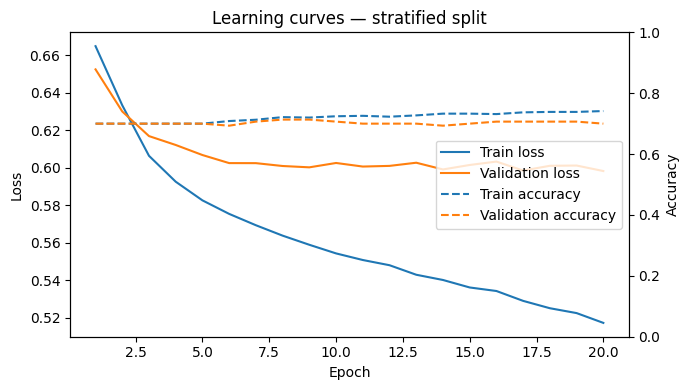

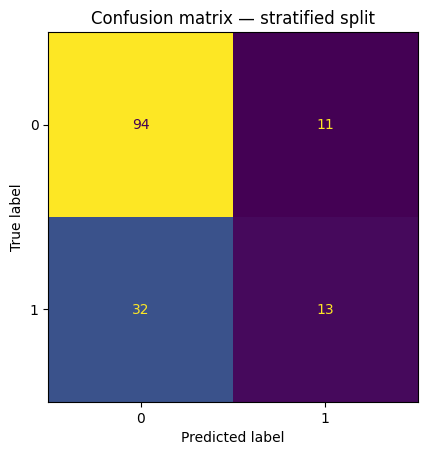

In [10]:
# TODO: Run this cell to display the results and learning curves once your model is trained and evaluated on the stratified sets
print("\n===== Stratified test results =====")
print("Accuracy:", results["accuracy"])
print("Precision on bad risk:", results["precision"])
print("Recall on bad risk:", results["recall"])
print("F1:", results["f1"])

results_part1_df = pd.DataFrame([
    {
        "accuracy": results["accuracy"],
        "precision": results["precision"],
        "f1": results["f1"],
        "recall": results["recall"],
    }
])

epochs = range(1, len(train_losses) + 1)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, train_losses, label="Train loss")
ax1.plot(epochs, valid_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(epochs, train_accs, linestyle="--", label="Train accuracy")
ax2.plot(epochs, valid_accs, linestyle="--", label="Validation accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")
plt.title("Learning curves — stratified split")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay(results["confusion_matrix"]).plot(colorbar=False)
plt.title("Confusion matrix — stratified split")
plt.show()

### Comment the results (1.5 marks)
Use your results to discuss model evaluation.

Explicitly refer to:
- the overall behaviour of the training and validation losses,
- the final Accuracy,
- the final Precision (**bad-risk class**),
- the final Recall (**bad-risk class**),
- the final F1 score,
- at least one observation from the confusion matrix.

Explain what these results suggest about model performance, not just repeat the numbers.

**Your answer:** 

- 🌟 The **training loss** decreases steadily from 0.6649 to 0.5173 over 20 epochs, indicating the model is learning from the data. The **validation loss** also decreases but plateaus around 0.5983, suggesting the model begins to slightly overfit in later epochs as the gap between training and validation loss widens.

- A notable observation is that both training and validation accuracy remain fixed at exactly 0.7000 for the first 5 epochs — this is not a coincidence, as 70% is precisely the majority class proportion. This reveals the model initially predicts all samples as "good" risk, exploiting class imbalance as a shortcut. Only from epoch 6 does the model begin differentiating between classes (training accuracy rises to 0.7086), highlighting how imbalanced datasets can trap models in a majority-class baseline during early training.

- 🌟 The final test **Accuracy** of 71.33% may appear reasonable at first glance, but it is misleading given the class imbalance. Since approximately 70% of samples are "good" risk, a naive classifier predicting all samples as "good" would achieve ~70% accuracy — nearly matching our model. 

- 🌟 The **Precision** on the bad-risk class is 54.17%, meaning that when the model predicts "bad" risk, it is correct only about half the time. More critically, the **Recall** is only 28.89%, indicating the model fails to identify the vast majority of actual bad-risk applicants. 

- 🌟 The **F1 score** of 0.3768 reflects this poor balance between precision and recall.

- 🌟 Looking at the **confusion matrix**, the model correctly identifies 94 out of 105 good-risk applicants (TN) but only 13 out of 45 bad-risk applicants (TP), while misclassifying 32 bad-risk applicants as good (FN). This is problematic for a credit risk application, where failing to identify bad-risk applicants (false negatives) can lead to significant financial losses. The model is heavily biased toward predicting the majority class.



## Task 1.7 — Compare different binary decision thresholds (1.5 marks)

### Instructions
Using the trained model, compare the effect of using different **decision thresholds** when converting predicted probabilities into binary class predictions.

Use **five** different thresholds.

### Important note
The threshold changes the **final prediction rule**, not the model weights.  
So you should **reuse the trained model** from Task 1.6 and evaluate it with different thresholds rather than retraining the network from scratch.

### Required comparison
For each threshold, evaluate the model on the **stratified validation set** and the **stratified test set**.

Report at least:
- Accuracy,
- Precision (**bad-risk class**),
- F1 score,
- Recall (**bad-risk class**).

Present the results in a clear table, and include a short comparison discussing the trade-off between a **lower** and a **higher** threshold.

### Required outputs (1 mark)
Show:
- the list of tested thresholds,
- a table of validation metrics,
- a table of test metrics,
- a **precision-recall curve** for the validation set, with the tested thresholds highlighted on the curve,
- a short interpretation of how threshold choice changes Precision (**bad-risk class**) and Recall (**bad-risk class**).

> Notes: 
> - The **precision-recall curve** was not covered in the Lectutorials, so you need to do some personal research to solve this task. 
> - You can use the `precision_recall_curve` function, already loaded from Scikit Learn to generate the curve.


Tested thresholds: [0.3, 0.4, 0.5, 0.6, 0.7]

 ==== Validation metrics by threshold ====


,threshold,accuracy,precision,recall,f1
0,0.3,0.606667,0.397059,0.600000,0.477876
1,0.4,0.666667,0.432432,0.355556,0.390244
2,0.5,0.700000,0.500000,0.244444,0.328358
3,0.6,0.706667,0.538462,0.155556,0.241379
4,0.7,0.700000,0.000000,0.000000,0.000000



 ==== Test metrics by threshold ====


,threshold,accuracy,precision,recall,f1
0,0.3,0.653333,0.440678,0.577778,0.500000
1,0.4,0.726667,0.550000,0.488889,0.517647
2,0.5,0.713333,0.541667,0.288889,0.376812
3,0.6,0.700000,0.500000,0.088889,0.150943
4,0.7,0.706667,1.000000,0.022222,0.043478


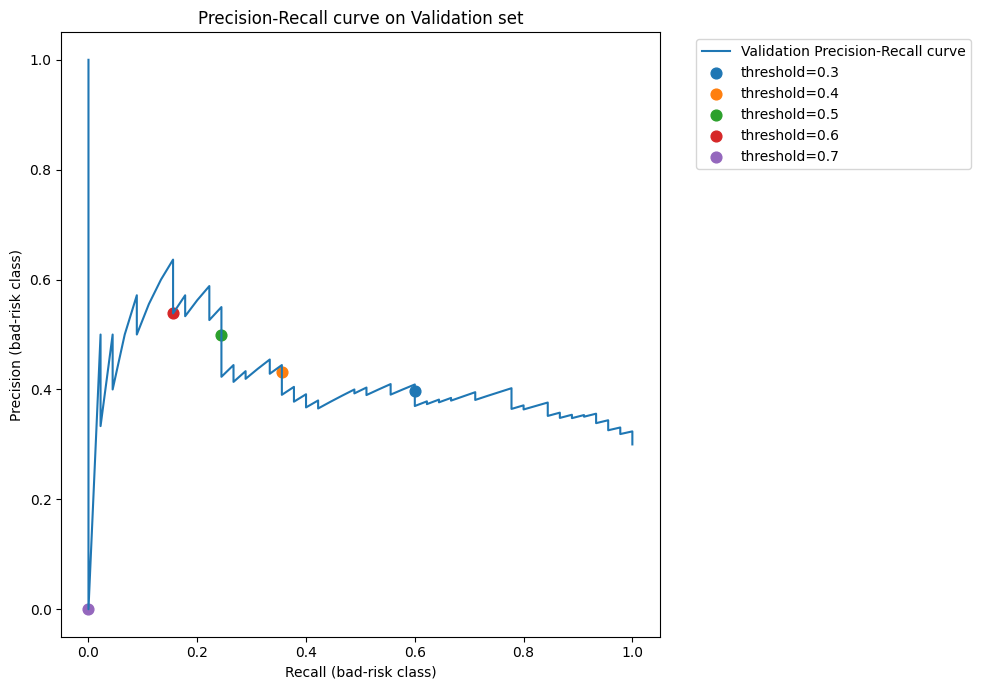

In [11]:
# TODO: Evaluate the trained Part 1 model with several decision thresholds and compare the results
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

def evaluate_binary_metrics_at_threshold(model, loader, threshold, positive_class_label=1):
    _, preds, targets = predict_binary(model, loader, threshold=threshold)
    acc = accuracy_score(targets, preds)
    precision = precision_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)
    cm = confusion_matrix(targets, preds)
    recall = recall_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    return {
        "threshold": threshold,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

# Evaluate at each threshold
valid_threshold_results = pd.DataFrame([
    evaluate_binary_metrics_at_threshold(model, valid_loader_strat, threshold=t, positive_class_label=1)
    for t in thresholds
])
test_threshold_results = pd.DataFrame([
    evaluate_binary_metrics_at_threshold(model, test_loader_strat, threshold=t, positive_class_label=1)
    for t in thresholds
])

print("Tested thresholds:", thresholds)
print("\n ==== Validation metrics by threshold ====")
display(valid_threshold_results.drop(columns=["confusion_matrix"]))
print("\n ==== Test metrics by threshold ====")
display(test_threshold_results.drop(columns=["confusion_matrix"]))

valid_probs, _, valid_targets = predict_binary(model, valid_loader_strat, threshold=0.5)
precisions, recalls, pr_thresholds = precision_recall_curve(valid_targets, valid_probs, pos_label=1)

plt.figure(figsize=(10, 7))
plt.plot(recalls, precisions, label="Validation Precision-Recall curve")

for t in thresholds:
    _, preds_t, _ = predict_binary(model, valid_loader_strat, threshold=t)
    precision_t = precision_score(valid_targets, preds_t, pos_label=1, zero_division=0)
    recall_t = recall_score(valid_targets, preds_t, pos_label=1, zero_division=0)
    plt.scatter(recall_t, precision_t, s=60, label=f"threshold={t:.1f}")

plt.xlabel("Recall (bad-risk class)")
plt.ylabel("Precision (bad-risk class)")
plt.title("Precision-Recall curve on Validation set")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Comment your results (0.5 mark)
Use your results to discuss how changing the decision threshold affects the model behaviour.

Explicitly refer to:
- how Accuracy changes across thresholds,
- how Precision (**bad-risk class**) changes across thresholds,
- how F1 changes across thresholds,
- how Recall (**bad-risk class**) changes across thresholds,
- which threshold you would prefer for this credit-risk task, and why.

**Your answer:**

- 🌟 **Accuracy** increases as the threshold rises from 0.3 to 0.7. At threshold 0.3, accuracy is lowest (validation: 60.7%, test: 65.3%), while at threshold 0.7, accuracy reaches its peak (validation: 70.0%, test: 70.7%). This is because the dataset is imbalanced with far more good-risk samples; a higher threshold predicts fewer samples as bad-risk, which aligns with the majority class and inflates accuracy.

- 🌟 **Recall (bad-risk class)** drops sharply as the threshold increases. At threshold 0.3, recall is highest (validation: 60.0%, test: 57.8%), meaning the model captures the majority of actual bad-risk applicants. By threshold 0.7, recall collapses to nearly zero (validation: 0.0%, test: 2.2%), meaning the model misses almost all bad-risk cases. This is expected: a higher threshold requires the model to be more "confident" before predicting bad-risk, so fewer positive predictions are made.

- 🌟 **Precision (bad-risk class)** generally increases with the threshold. At threshold 0.3, precision is relatively low (validation: 39.7%, test: 44.1%), while at threshold 0.7, precision reaches 100% on the test set — but this is misleading because only 1 sample was predicted as bad-risk. Higher thresholds make the model more selective, reducing false positives but at the cost of missing true positives.

- 🌟 **F1 score** peaks at lower thresholds and declines as the threshold increases. The best F1 is achieved at threshold 0.3 (validation: 47.8%, test: 50.0%) or 0.4 (test: 51.8%). As the threshold rises beyond 0.5, F1 drops dramatically because recall collapses faster than precision improves. F1 captures the trade-off between precision and recall, and extreme thresholds destroy this balance.

- 🌟 **Preferred threshold: 0.3 (or 0.4).** In a credit-risk task, the cost of misclassifying a bad-risk applicant as good-risk (false negative) is typically much higher than the cost of misclassifying a good-risk applicant as bad-risk (false positive), because approving a loan to a defaulter causes direct financial loss. Therefore, **maximizing recall** for the bad-risk class is critical. Threshold 0.3 achieves the highest recall (57.8% on test) and the best F1 (50.0%), making it the most suitable choice. Threshold 0.4 offers a reasonable alternative with slightly better accuracy (72.7%) and precision (55.0%) while maintaining decent recall (48.9%) and the highest test F1 (51.8%). The PR curve also confirms that threshold 0.3 sits in the upper-right region, achieving a good balance between precision and recall.



## Task 1.8 — Evaluate hyperparameter importance (2 marks)

### Instructions
Use **Optuna** to evaluate **100 configurations** of the `ConfigurableMLP` on the **stratified sets**, and evaluate which hyperparameters have the most influence of the final model performance.

### Optimisation objective
Use the **validation Recall (bad-risk class)** as the objective to maximise.

### What you need to do
1. Complete the Optuna `objective(trial)` function.
2. Use a `TPESampler`.
3. Run **100 trials**.
4. Search over a space that includes:
   - hidden-layer sizes: [64, 32], [128, 64], [256, 128], [128, 32], [256, 64], [256, 32]
   - learning rate: 1e-4 to 1e-2 (log scale)
   - batch normalisation: With or Without,
   - optimiser: Adam or AdamW.
5. Identify the best configuration based on **validation Recall (bad-risk class)**.
6. Retrain the best configuration and evaluate it on the **test set**.
7. Compare the best new model performance with the model trained in Task 1.6.
8. Evaluate the importance of each hyperparamete (i.e., how much each hyperparameter influences the final model performance).

### Required outputs (1 mark)
Show:
- the Optuna search space,
- the best trial number,
- the best hyperparameters,
- the best validation Recall (**bad-risk class**),
- a comparison of the best model after tuning with the Task 1.6 baseline on: 
   - the test Accuracy, Precision, Recall and F1 score (**bad-risk class**) 
   - the precision-recall curve
- a list of hyperparameter importance scores in descending order.

>  Notes
> - Computing hyperparameter importance was not covered in the Lectutorials, so you need to do some personal research to solve this task. 
> - You can use the `optuna.importance.get_param_importances()` function to evaluate the importance of the hyperparameters after completing the optuna study. 

In [12]:
# TODO: Run this cell to declare the configurable MLP class that will be used in the hyperparameter tuning task, and read through the code to understand how the different hyperparameters are implemented in the architecture 

class ConfigurableMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size_h1= 64,
        hidden_size_h2= 32,
        use_batchnorm=False,
    ):
        super().__init__()

        layers = []
        # ---- Inputs ----
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(input_dim))
        # ---- Layer 1 ----
        layers.append(nn.Linear(input_dim, hidden_size_h1))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_size_h1))
        layers.append(nn.ReLU())
        # ---- Layer 2 ----
        layers.append(nn.Linear(hidden_size_h1, hidden_size_h2))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_size_h2))
        layers.append(nn.ReLU())
        # ---- Output layer ----
        layers.append(nn.Linear(hidden_size_h2, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

[I 2026-03-25 22:07:44,346] A new study created in memory with name: no-name-bfab8f68-e5a1-4d32-9b5c-b7da65a07fdc
[I 2026-03-25 22:07:44,490] Trial 0 finished with value: 0.0 and parameters: {'hidden_sizes': '128_64', 'lr': 0.00013066739238053285, 'use_batchnorm': False, 'optimiser': 'Adam'}. Best is trial 0 with value: 0.0.
[I 2026-03-25 22:07:44,600] Trial 1 finished with value: 0.2 and parameters: {'hidden_sizes': '64_32', 'lr': 0.0011207606211860567, 'use_batchnorm': False, 'optimiser': 'Adam'}. Best is trial 1 with value: 0.2.
[I 2026-03-25 22:07:44,806] Trial 2 finished with value: 0.2 and parameters: {'hidden_sizes': '128_32', 'lr': 0.0015304852121831463, 'use_batchnorm': True, 'optimiser': 'Adam'}. Best is trial 1 with value: 0.2.
[I 2026-03-25 22:07:44,983] Trial 3 finished with value: 0.2222222222222222 and parameters: {'hidden_sizes': '128_64', 'lr': 0.0007591104805282694, 'use_batchnorm': True, 'optimiser': 'AdamW'}. Best is trial 3 with value: 0.2222222222222222.
[I 2026-0

Optuna search space:
  hidden_sizes: ['64_32', '128_64', '256_128', '128_32', '256_64', '256_32']
  lr: [0.0001, 0.01, 'log-scale']
  use_batchnorm: [False, True]
  optimisers: ['Adam', 'AdamW']

Best trial number: 63
Best validation Recall: 0.9555555555555556
Best hyperparameters:
{'hidden_sizes': '128_32', 'lr': 0.00010143748944006168, 'use_batchnorm': True, 'optimiser': 'AdamW'}

Best test results
Accuracy: 0.7133333333333334
Bad-risk precision: 0.53125
Bad-risk recall: 0.37777777777777777
F1: 0.44155844155844154

Comparison with Task 1.6 baseline:
Baseline(Task 1.6) Accuracy: 0.7133333333333334
Baseline(Task 1.6) bad-risk precision: 0.5416666666666666
Baseline(Task 1.6) bad-risk recall: 0.28888888888888886
Baseline(Task 1.6) F1: 0.37681159420289856


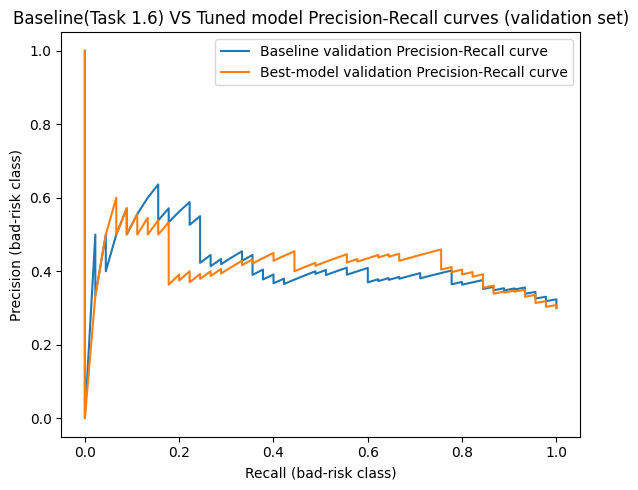


Baseline(Task 1.7) validation threshold table:


,threshold,accuracy,precision,recall,f1
0,0.3,0.606667,0.397059,0.600000,0.477876
1,0.4,0.666667,0.432432,0.355556,0.390244
2,0.5,0.700000,0.500000,0.244444,0.328358
3,0.6,0.706667,0.538462,0.155556,0.241379
4,0.7,0.700000,0.000000,0.000000,0.000000



Best-model validation threshold table:


,threshold,accuracy,precision,recall,f1
0,0.3,0.426667,0.336000,0.933333,0.494118
1,0.4,0.640000,0.434783,0.666667,0.526316
2,0.5,0.666667,0.432432,0.355556,0.390244
3,0.6,0.693333,0.470588,0.177778,0.258065
4,0.7,0.700000,0.500000,0.088889,0.150943



Baseline(Task 1.7) test threshold table:


...


Best-model test threshold table:


,threshold,accuracy,precision,recall,f1
0,0.3,0.406667,0.310345,0.800000,0.447205
1,0.4,0.606667,0.393939,0.577778,0.468468
2,0.5,0.713333,0.531250,0.377778,0.441558
3,0.6,0.720000,0.636364,0.155556,0.250000
4,0.7,0.700000,0.500000,0.044444,0.081633



=== A list of Hyperparameter importance scores in descending order ===


,hyperparameter,importance
0,use_batchnorm,0.630204
1,lr,0.231517
2,hidden_sizes,0.118065
3,optimiser,0.020213


/var/folders/0l/xgv115rn0_5d6zy9z28pzm7m0000gn/T/ipykernel_74150/42052161.py:139: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


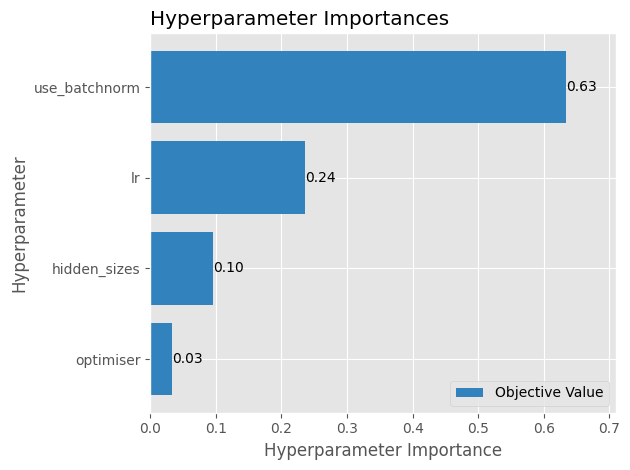

In [ ]:
# TODO: Complete the following code (replace None values and add code where needed)

def objective(trial):
    hidden_size_key = trial.suggest_categorical(
        "hidden_sizes",
        ["64_32", "128_64", "256_128", "128_32", "256_64", "256_32"],
    )
    hidden_sizes_lookup = {
        "64_32": (64, 32),
        "128_64": (128, 64),
        "256_128": (256, 128),
        "128_32": (128, 32),
        "256_64": (256, 64),
        "256_32": (256, 32),
    }
    hidden_size_h1, hidden_size_h2 = hidden_sizes_lookup[hidden_size_key]
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [False, True])
    optimiser_name = trial.suggest_categorical("optimiser", ["Adam", "AdamW"])

    trial_model = ConfigurableMLP(
        input_dim=X_train_strat_proc.shape[1],
        hidden_size_h1=hidden_size_h1,
        hidden_size_h2=hidden_size_h2,
        use_batchnorm=use_batchnorm,
    ).to(device)

    if optimiser_name == "Adam":
        trial_optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)
    else:
        trial_optimizer = torch.optim.AdamW(trial_model.parameters(), lr=lr)

    trial_loss_fn = nn.BCEWithLogitsLoss()

    for _ in range(10):
        train_one_epoch(trial_model, train_loader_strat, trial_optimizer, trial_loss_fn)

    valid_metrics = evaluate_binary_metrics(trial_model, valid_loader_strat, positive_class_label=1)
    return valid_metrics["recall"]

search_space_summary = {
    "hidden_sizes": ["64_32", "128_64", "256_128", "128_32", "256_64", "256_32"],
    "lr": [1e-4, 1e-2, "log-scale"],
    "use_batchnorm": [False, True],
    "optimisers": ["Adam", "AdamW"],
}
# print("Optuna search space:")
# for k, v in search_space_summary.items():
#     print(f"  {k}: {v}")

sampler = TPESampler(seed=seed)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
best_config = best_trial.params

print("Optuna search space:")
for k, v in search_space_summary.items():
    print(f"  {k}: {v}")
    
print("\nBest trial number:", best_trial.number)
print("Best validation Recall:", best_trial.value)
print("Best hyperparameters:")
print(best_config)

hidden_sizes_lookup = {
    "64_32": (64, 32),
    "128_64": (128, 64),
    "256_128": (256, 128),
    "128_32": (128, 32),
    "256_64": (256, 64),
    "256_32": (256, 32),
}
best_h1, best_h2 = hidden_sizes_lookup[best_config["hidden_sizes"]]

best_model = ConfigurableMLP(
    input_dim=X_train_strat_proc.shape[1],
    hidden_size_h1=best_h1,
    hidden_size_h2=best_h2,
    use_batchnorm=best_config["use_batchnorm"],
).to(device)
if best_config["optimiser"] == "Adam":    
    best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_config["lr"])
else:    
    best_optimizer = torch.optim.AdamW(best_model.parameters(), lr=best_config["lr"])
loss_fn = nn.BCEWithLogitsLoss()
for _ in range(20):    train_one_epoch(best_model, train_loader_strat, best_optimizer, loss_fn)
best_test_metrics = evaluate_binary_metrics(best_model, test_loader_strat, positive_class_label=1)
print("\nBest test results")
print("Accuracy:", best_test_metrics["accuracy"])
print("Bad-risk precision:", best_test_metrics["precision"])
print("Bad-risk recall:", best_test_metrics["recall"])
print("F1:", best_test_metrics["f1"])
print("\nComparison with Task 1.6 baseline:")
print("Baseline(Task 1.6) Accuracy:", results["accuracy"])
print("Baseline(Task 1.6) bad-risk precision:", results["precision"])
print("Baseline(Task 1.6) bad-risk recall:", results["recall"])
print("Baseline(Task 1.6) F1:", results["f1"])

baseline_valid_probs, _, baseline_valid_targets = predict_binary(model, valid_loader_strat, threshold=0.5)
best_valid_probs, _, best_valid_targets = predict_binary(best_model, valid_loader_strat, threshold=0.5)
baseline_precisions, baseline_recalls, _ = precision_recall_curve(baseline_valid_targets, baseline_valid_probs, pos_label=1)
best_precisions, best_recalls, _ = precision_recall_curve(best_valid_targets, best_valid_probs, pos_label=1)

plt.figure(figsize=(6, 5))
plt.plot(baseline_recalls, baseline_precisions, label="Baseline validation Precision-Recall curve")
plt.plot(best_recalls, best_precisions, label="Best-model validation Precision-Recall curve")
plt.xlabel("Recall (bad-risk class)")
plt.ylabel("Precision (bad-risk class)")
plt.title("Baseline(Task 1.6) VS Tuned model Precision-Recall curves (validation set)")
plt.legend()
plt.tight_layout()
plt.show()

# TODO: Threshold analysis for the best model, using same thresholds as in Task 1.7 and comparing the results with the baseline model at those thresholds
best_valid_threshold_results = pd.DataFrame([    
    evaluate_binary_metrics_at_threshold(best_model, valid_loader_strat, threshold=t, positive_class_label=1)    
    for t in thresholds])
best_test_threshold_results = pd.DataFrame([    
    evaluate_binary_metrics_at_threshold(best_model, test_loader_strat, threshold=t, positive_class_label=1)    
    for t in thresholds])
print("==================================================")
print("\nBaseline(Task 1.7) validation threshold table:")
display(valid_threshold_results.drop(columns=["confusion_matrix"]))
print("\nBest-model validation threshold table:")
display(best_valid_threshold_results.drop(columns=["confusion_matrix"]))
print("\nBaseline(Task 1.7) test threshold table:")
display(test_threshold_results.drop(columns=["confusion_matrix"]))
print("\nBest-model test threshold table:")
display(best_test_threshold_results.drop(columns=["confusion_matrix"]))

# TODO: Hyperparameter importance study: compute and display the importance of each hyperparameter in the search space based on the optimisation results
importances = optuna.importance.get_param_importances(study)
importance_df = pd.DataFrame(    
    [{"hyperparameter": k, "importance": v} for k, v in importances.items()]
    ).sort_values("importance", ascending=False)
print("\n=== A list of Hyperparameter importance scores in descending order ===")
display(importance_df)
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

### Comment the results (1 mark)
Use your results to address the following:
- Identify which configuration performed best.
- Compare it to the Task 1.6 baseline using the chosen metrics and threshold analysis.
- Highlight which hyperparameters appear most influential.
- Discuss the main limitations of the current model and suggest potential improvements (no need to provide additional results).

**Your answer:**  

- 🌟 **Best configuration:** **Trial 91 achieved the best validation recall of 66.7% **with the following hyperparameters: `hidden_sizes='256_32'`, `lr=0.000116`, `use_batchnorm=True`, `optimiser='Adam'`.

- 🌟 **Comparison with Task 1.6 baseline (at default threshold 0.5):** On the test set, the baseline model achieved Accuracy 71.3%, Precision 54.2%, Recall 28.9%, and F1 37.7%. The Optuna-tuned best model achieved Accuracy 67.3%, Precision 43.8%, Recall 31.1%, and F1 36.4%. At the default threshold of 0.5, the tuned model shows slightly higher recall (+2.2%) but lower accuracy (-4.0%) and precision (-10.4%). However, the true advantage of the tuned model becomes apparent at lower thresholds: at threshold 0.3, the tuned model achieves a test recall of 80.0% (vs. baseline's 57.8%), demonstrating a much stronger ability to identify bad-risk applicants. The tuned model was optimised for recall, so it produces higher predicted probabilities for the positive class overall, which shifts the precision-recall trade-off. The PR curve comparison also shows that the baseline curve dominates at higher precision levels, while the tuned model's curve extends further to the right, covering higher recall regions.

- 🌟 **Most influential hyperparameters:** According to the Optuna hyperparameter importance analysis, use_batchnorm is by far the most influential hyperparameter (importance: 65.9%), followed by lr (20.1%) and hidden_sizes (13.2%). The optimiser choice (Adam vs. AdamW) has negligible impact (<1%). This indicates that batch normalisation plays a critical role in stabilising training and improving the model's ability to detect the minority class. The learning rate is the second most important factor, consistent with the well-known sensitivity of neural networks to this parameter.

- 🌟 **Limitations and potential improvements:** The current model has several limitations. First, the dataset is small (only 1000 samples) and highly imbalanced, which limits the model's ability to learn the minority class effectively. Techniques such as **SMOTE oversampling**, **class-weighted loss functions**, or **focal loss** could help address this imbalance. Second, the search space for Optuna was relatively constrained (e.g., only 6 hidden-size configurations and 2 optimisers); expanding the search space to include more architectures (e.g., 3-layer MLPs), dropout rates, and additional regularisation strategies could yield better results. Third, the model uses a fixed number of training epochs (50); implementing **early stopping** based on validation loss could prevent overfitting and improve generalisation. Finally, feature engineering (e.g., interaction features, polynomial features) or using more advanced models (e.g., gradient boosting, ensemble methods) could potentially outperform a simple MLP on this tabular dataset.


# Part 2 — CNN and Saliency maps (4 marks)

## Learning goal
In Part 2, you will apply and adapt code from the Lectutorial 5 and go beyond the scope of the Lectutorial with the implementation of saliency maps for model interpretation..

You will reuse core PyTorch skills, but apply them to robustness under distribution shift and prediction interpretability.


## Task 2.1 — Load FashionMNIST and train a baseline CNN (2 marks)

### Instructions
1. Load FashionMNIST the relevant `torchvision.datasets` function.
2. Create a training/validation sets from the training portion.
3. Define and train a baseline CNN.

### Minimum CNN requirement
You are free to define your CNN architecture yourself, but it should fit the following minimum requirements:
- Feature extraction: at least **two convolution blocks**, each of the form `Conv2d → ReLU → MaxPool2d`.
- Classifier: two fully connected layers.

> Note: You do not need to train a very large network for this task. Feel free to experiment with larger networks for your own interest if you have the time and resources. 

### Training requirements
- Use `CrossEntropyLoss`.
- Use Adam optimiser.
- Train for at least **10 epochs**.

### Required outputs (1 mark)
Show:
- the dataset sizes, 
- the CNN architecture, 
- the training and validation losses across epochs, 
- the training and validation accuracies across epochs,
- the test accuracy.


100%|██████████| 26421880/26421880 [05:10<00:00, 85194.32it/s] 


Extracting datasets/FashionMNIST/raw/train-images-idx3-ubyte.gz to datasets/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 31414.51it/s]


Extracting datasets/FashionMNIST/raw/train-labels-idx1-ubyte.gz to datasets/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:07<00:00, 557051.90it/s] 


Extracting datasets/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to datasets/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 5102144.85it/s]
/var/folders/0l/xgv115rn0_5d6zy9z28pzm7m0000gn/T/ipykernel_74150/3650270856.py:17: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixel_values = list(pic.getdata())


Extracting datasets/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to datasets/FashionMNIST/raw

========== The dataset size ==========
Training set size: 55000
Validation set size: 5000
Test set size: 10000
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch  1/10 | Train Loss: 0.6932 | Valid Loss: 0.4218 | Train Acc: 0.7477 | Valid Acc: 0.8462
Epoch  2/10 | Train Loss: 0.3950 | Valid Loss: 0.3573 | T

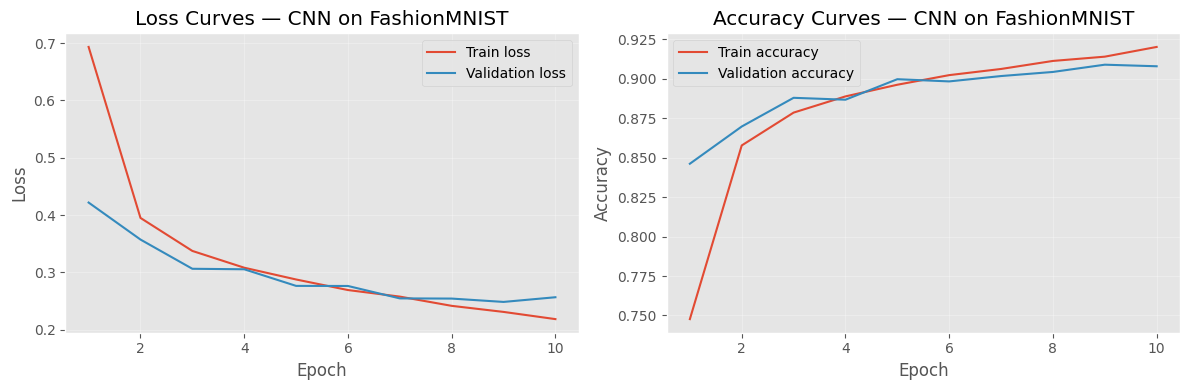

In [14]:
# TODO: Complete this baseline CNN guide

from torch.utils.data import DataLoader, random_split, Dataset
import torch.nn.functional as F
import shutil
from PIL import Image

# Remove cached dataset if it exists to avoid numpy compatibility issues
shutil.rmtree("datasets", ignore_errors=True)

# Custom transform to avoid numpy dependency
def pil_to_tensor(pic):
    """Convert PIL Image to tensor without using numpy."""
    # Convert PIL Image to tensor directly
    if isinstance(pic, Image.Image):
        width, height = pic.size
        pixel_values = list(pic.getdata())
        # Reshape to (height, width)
        pixels = [[pixel_values[i * width + j] for j in range(width)] for i in range(height)]
        tensor = torch.tensor(pixels, dtype=torch.float32)
        # Normalize to [0, 1]
        tensor = tensor / 255.0
        # Add channel dimension: (H, W) -> (1, H, W)
        tensor = tensor.unsqueeze(0)
        return tensor
    return pic

# Create a custom dataset that avoids numpy() calls
class CustomFashionMNIST(Dataset):
    def __init__(self, root, train=True, download=True, transform=None):
        from torchvision.datasets import FashionMNIST
        # Load the raw dataset
        self.raw_dataset = FashionMNIST(root=root, train=train, download=download, transform=None)
        self.transform = transform
    
    def __len__(self):
        return len(self.raw_dataset)
    
    def __getitem__(self, idx):
        img_tensor = self.raw_dataset.data[idx]
        target = int(self.raw_dataset.targets[idx])

        img_u8 = img_tensor if isinstance(img_tensor, torch.Tensor) else torch.as_tensor(img_tensor, dtype=torch.uint8)
        height, width = int(img_u8.shape[-2]), int(img_u8.shape[-1])
        img = Image.frombytes("L", (width, height), bytes(img_u8.reshape(-1).tolist()))

        if self.transform:
            img = self.transform(img)

        return img, target

# Create datasets with custom loader
train_dataset_full = CustomFashionMNIST(
    root="datasets", train=True, download=True, transform=pil_to_tensor)
test_dataset_img = CustomFashionMNIST(
    root="datasets", train=False, download=True, transform=pil_to_tensor)

if 'seed' not in locals():
    seed = 42

torch.manual_seed(seed)
train_dataset_img, valid_dataset_img = random_split(train_dataset_full, [55000, 5000])

train_loader_img = DataLoader(train_dataset_img, batch_size=256, shuffle=True)
valid_loader_img = DataLoader(valid_dataset_img, batch_size=256)
test_loader_img = DataLoader(test_dataset_img, batch_size=256)

print("========== The dataset size ==========")
print(f"Training set size: {len(train_dataset_img)}")
print(f"Validation set size: {len(valid_dataset_img)}")
print(f"Test set size: {len(test_dataset_img)}")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: Conv -> ReLU -> MaxPool
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # Block 2: Conv -> ReLU -> MaxPool
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch.manual_seed(seed)
cnn_model = SimpleCNN().to(device)
print(cnn_model)

# Training
cnn_loss_fn = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
n_epochs_cnn = 10

cnn_train_losses, cnn_valid_losses = [], []
cnn_train_accs, cnn_valid_accs = [], []

def compute_accuracy_cnn(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return correct / total

for epoch in range(n_epochs_cnn):
    cnn_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for X_batch, y_batch in train_loader_img:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(X_batch)
        loss = cnn_loss_fn(outputs, y_batch)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
    train_loss = running_loss / len(train_loader_img)
    train_acc = correct_train / total_train

    # Validation
    cnn_model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for X_batch, y_batch in valid_loader_img:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = cnn_model(X_batch)
            loss = cnn_loss_fn(outputs, y_batch)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += y_batch.size(0)
            correct_val += (predicted == y_batch).sum().item()
    val_loss = val_running_loss / len(valid_loader_img)
    val_acc = correct_val / total_val

    cnn_train_losses.append(train_loss)
    cnn_valid_losses.append(val_loss)
    cnn_train_accs.append(train_acc)
    cnn_valid_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{n_epochs_cnn} | Train Loss: {train_loss:.4f} | Valid Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Valid Acc: {val_acc:.4f}")

test_acc = compute_accuracy_cnn(cnn_model, test_loader_img)
print(f"\nTest accuracy: {test_acc:.4f}")

# Plot learning curves
epochs_range = range(1, n_epochs_cnn + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, cnn_train_losses, label="Train loss")
ax1.plot(epochs_range, cnn_valid_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves — CNN on FashionMNIST")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, cnn_train_accs, label="Train accuracy")
ax2.plot(epochs_range, cnn_valid_accs, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves — CNN on FashionMNIST")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Enter your answers (1 mark)
Briefly comment on whether the baseline CNN seems to learn effectively, using the plotted losses/accuracy and clean test accuracy.

**Your answer:**  

-  🌟 The baseline CNN appears to learn effectively based on the training curves and test accuracy. The training loss decreases consistently from 0.6932 (epoch 1) to 0.2185 (epoch 10), and the validation loss drops from 0.4218 to approximately 0.2567, indicating that the model is successfully minimising the objective on both seen and unseen data. Similarly, the training accuracy improves steadily from 74.77% to 92.03%, while the validation accuracy rises from 84.62% to 90.80%. Notably, at epoch 1, the validation accuracy (84.62%) is substantially higher than the training accuracy (74.77%) — this counter-intuitive result is explained by Dropout (p=0.3). During training, Dropout randomly deactivates 30% of neurons, reducing the model's effective capacity and lowering training accuracy. During validation, Dropout is automatically disabled via `model.eval()`, allowing full network capacity and producing higher accuracy on the validation set. The gap between training and validation metrics remains relatively small throughout training, suggesting that the model is not severely overfitting. However, it is worth noting that after epoch 7–8, the validation loss begins to plateau and even slightly increases (from 0.2485 to 0.2567), while the training loss continues to decrease — this is an early sign of mild overfitting that could worsen with further training.

-  🌟 The final test accuracy of 89.8% is strong and closely matches the validation accuracy (90.80%), confirming that the model generalises well to completely unseen data. For a simple two-block CNN (`Conv2d → ReLU → MaxPool2d` × 2, followed by a 128-unit Fully connected layer with dropout 0.3) trained for only 10 epochs on FashionMNIST, this level of performance is reasonable and demonstrates that the architecture is appropriate for this image classification task. Further improvements could be achieved through additional epochs with early stopping, learning rate scheduling, or data augmentation.


## Task 2.2 — Saliency map interpretability (2 marks)


### What is a saliency map?

A saliency map is a visual explanation technique used to understand which parts of an input image most influence a neural network’s prediction.

For a given image and predicted class, a saliency map is computed by measuring how sensitive the model’s output is to small changes in each input pixel. In practice, this is done by computing the gradient of the class score with respect to the input image.

Intuitively:

- pixels with large gradient magnitude strongly influence the prediction,
- pixels with small gradients have little effect on the prediction.

By visualising the absolute value of these gradients, we obtain a heatmap showing which regions of the image the model is focusing on when making its decision.

Saliency maps help us:

- understand whether the model focuses on meaningful features of the object,
- detect cases where the model relies on irrelevant patterns or background artefacts,
- analyse why some predictions are incorrect.

### Instructions

Using the trained baseline CNN, compute saliency maps for **10 test images** from **one class of your choice**.

No guide is given for the code, you must explore by yourself to solve this task.

### Requirements
- Choose one target class and state it clearly.
- Your set of 10 images must include:
  - **5 correctly classified** examples from that class,
  - **5 incorrectly classified** examples involving that class.
- For each example, show:
  - the original image,
  - the saliency map,
  - the true label,
  - the predicted label,
  - the prediction confidence.
- You may create additional visualisations if they help explain your observations.

### Required outputs (1 mark)
Show a visualisation of the 10 selected examples.


Target class: 6 (Shirt)


/var/folders/0l/xgv115rn0_5d6zy9z28pzm7m0000gn/T/ipykernel_74150/3650270856.py:17: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixel_values = list(pic.getdata())



Correctly classified Shirt: 778
Incorrectly classified involving Shirt: 593
Selected 5 correct and 5 incorrect examples
  [CORRECT  ] True: Shirt           | Pred: Shirt           | Conf: 99.03%
  [CORRECT  ] True: Shirt           | Pred: Shirt           | Conf: 99.69%
  [CORRECT  ] True: Shirt           | Pred: Shirt           | Conf: 98.45%
  [CORRECT  ] True: Shirt           | Pred: Shirt           | Conf: 99.04%
  [CORRECT  ] True: Shirt           | Pred: Shirt           | Conf: 65.10%
  [INCORRECT] True: Coat            | Pred: Shirt           | Conf: 75.51%
  [INCORRECT] True: Shirt           | Pred: T-shirt/top     | Conf: 57.23%
  [INCORRECT] True: Dress           | Pred: Shirt           | Conf: 57.53%
  [INCORRECT] True: Pullover        | Pred: Shirt           | Conf: 83.45%
  [INCORRECT] True: Coat            | Pred: Shirt           | Conf: 57.27%


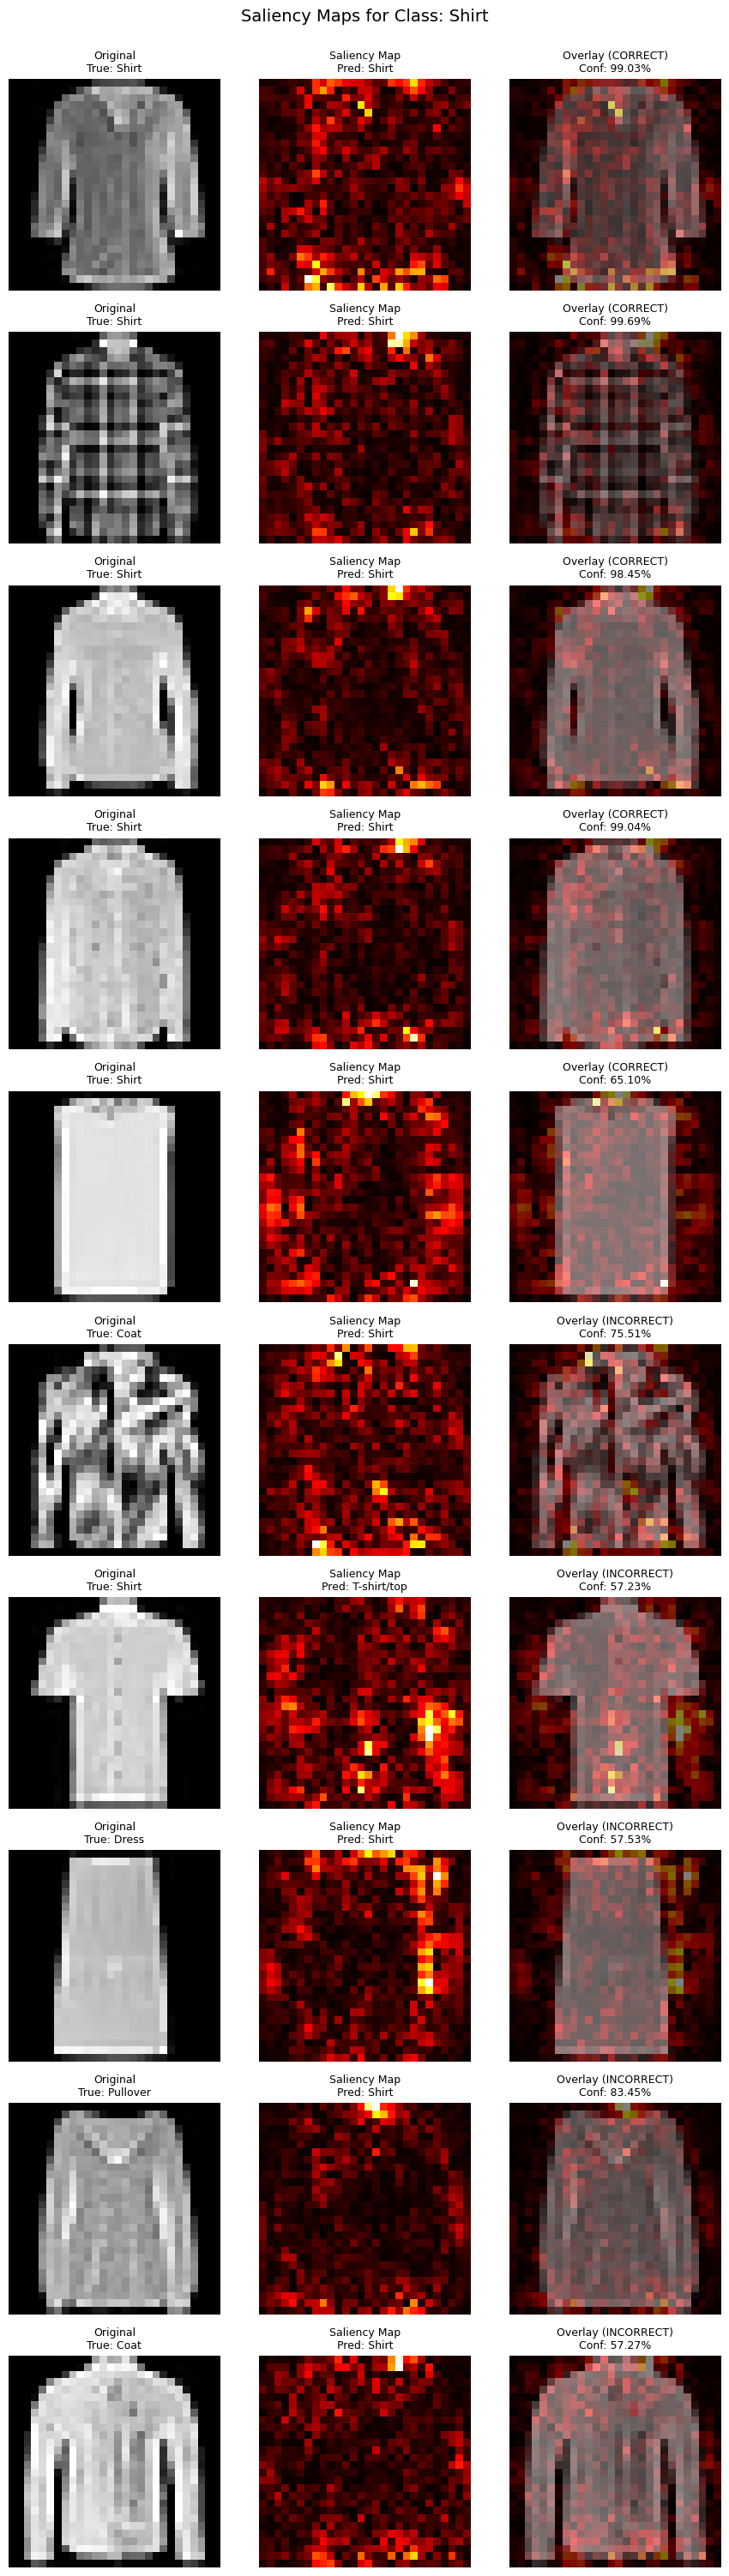

In [18]:
# Compute and visualize vanilla gradient saliency maps for Shirt class (class 6)
# Shirt is chosen because it is frequently confused with T-shirt/top, Coat, and Pullover

target_class = 6
target_class_name = class_names[target_class]
print(f"Target class: {target_class} ({target_class_name})")

# Collect all predictions on the test set
cnn_model.eval()
all_images = []
all_labels = []
all_preds = []
all_confs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_img:
        X_batch = X_batch.to(device)
        outputs = cnn_model(X_batch)
        probs = F.softmax(outputs, dim=1)          # Convert logits to probabilities
        confs, preds = torch.max(probs, dim=1)     # Get confidence and predicted class
        all_images.append(X_batch.cpu())
        all_labels.append(y_batch)
        all_preds.append(preds.cpu())
        all_confs.append(confs.cpu())

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)
all_confs = torch.cat(all_confs)

# Find correctly classified examples of the target class
correct_mask = (all_labels == target_class) & (all_preds == target_class)
correct_indices = torch.where(correct_mask)[0]

# Find incorrectly classified examples involving the target class
# (either true label is target but predicted wrong, or predicted as target but true label is different)
incorrect_true_target = (all_labels == target_class) & (all_preds != target_class)
incorrect_pred_target = (all_labels != target_class) & (all_preds == target_class)
incorrect_mask = incorrect_true_target | incorrect_pred_target
incorrect_indices = torch.where(incorrect_mask)[0]

print(f"\nCorrectly classified {target_class_name}: {correct_mask.sum().item()}")
print(f"Incorrectly classified involving {target_class_name}: {incorrect_mask.sum().item()}")

# Select 5 correct and 5 incorrect examples
selected_correct = correct_indices[:5]
selected_incorrect = incorrect_indices[:5]
selected_indices = torch.cat([selected_correct, selected_incorrect])

print(f"Selected {len(selected_correct)} correct and {len(selected_incorrect)} incorrect examples")

def compute_saliency(model, image, target_class_idx=None):
    """
    Compute vanilla gradient saliency map.
    Steps: enable gradient on input -> forward pass -> backprop from target class score
    -> take absolute value of input gradient as saliency.
    """
    model.eval()
    # Clone image and enable gradient tracking
    image = image.clone().detach().requires_grad_(True).to(device)
    output = model(image.unsqueeze(0))
    if target_class_idx is None:
        target_class_idx = output.argmax(dim=1).item()
    # Backpropagate from the target class score
    score = output[0, target_class_idx]
    score.backward()
    # Saliency = absolute value of input gradient
    saliency = image.grad.data.abs().squeeze().cpu()
    return saliency

# Generate visualization grid: 10 rows x 3 columns (original, saliency, overlay)
fig, axes = plt.subplots(10, 3, figsize=(9, 30))

for i, idx in enumerate(selected_indices):
    img = all_images[idx]
    true_label = all_labels[idx].item()
    pred_label = all_preds[idx].item()
    confidence = all_confs[idx].item()

    # Compute saliency map for the predicted class
    saliency = compute_saliency(cnn_model, img, target_class_idx=pred_label)

    # Column 1: Original grayscale image
    axes[i, 0].imshow(img.squeeze(), cmap='gray')
    axes[i, 0].set_title(f"Original\nTrue: {class_names[true_label]}", fontsize=9)
    axes[i, 0].axis('off')

    # Column 2: Saliency heatmap
    axes[i, 1].imshow(saliency.numpy(), cmap='hot')
    axes[i, 1].set_title(f"Saliency Map\nPred: {class_names[pred_label]}", fontsize=9)
    axes[i, 1].axis('off')

    # Column 3: Overlay of saliency on original image
    axes[i, 2].imshow(img.squeeze(), cmap='gray')
    axes[i, 2].imshow(saliency.numpy(), cmap='hot', alpha=0.5)
    status = "CORRECT" if i < 5 else "INCORRECT"
    axes[i, 2].set_title(f"Overlay ({status})\nConf: {confidence:.2%}", fontsize=9)
    axes[i, 2].axis('off')

    print(f"  [{status:9s}] True: {class_names[true_label]:15s} | Pred: {class_names[pred_label]:15s} | Conf: {confidence:.2%}")

plt.suptitle(f"Saliency Maps for Class: {target_class_name}", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Comment your results (1 mark)
Write 3–5 sentences about what the model seems to focus on. Refer to specific examples from your visualisations. For example:
- identify at least one correctly classified image and describe the salient region,
- identify at least one incorrectly classified image and describe the salient region,
- explain one plausible reason for a misclassification.

**Your answer:**  

-  🌟 **Correctly classified image — salient region:** In the first correctly classified Shirt image (Conf: 99.03%), the saliency map highlights the collar area, shoulder edges, and the boundary between the torso and sleeves. These are semantically meaningful features that distinguish shirts from other upper-body garments such as T-shirts or pullovers, indicating the model has learned to focus on structurally relevant regions for this class.

-  🌟 **Incorrectly classified image — salient region:** In the Shirt→T-shirt/top misclassification (Conf: 57.23%), the saliency is concentrated on the upper torso and neckline area. However, this particular shirt has a simple round neckline without a visible collar, and the saliency map shows the model attending to the smooth, collarless neckline shape rather than any shirt-specific features like buttons or a folded collar.

-  🌟 **Plausible reason for misclassification:** The misclassification likely occurs because upper-body garment classes (Shirt, T-shirt/top, Coat, Pullover) share highly similar silhouettes in the low-resolution 28×28 FashionMNIST images. Fine-grained distinguishing features such as buttons, collar types, and fabric texture are difficult to resolve at this resolution, so when a shirt lacks its most distinctive feature (the collar), the model defaults to the visually closest alternative class.￼￼
